In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
import torch
import torch.nn as nn
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128,128)):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU(), nn.LayerNorm(h)]
            d = h
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def reparam(mu, logvar):
    eps = torch.randn_like(mu)
    return mu + eps * torch.exp(0.5 * logvar)

class DiagGaussianHead(nn.Module):
    """Outputs (mu, log_sigma) for R^3."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = MLP(in_dim, out_dim, hidden=(128,128))
    def forward(self, x):
        out = self.mlp(x)
        mu, log_sig = out[..., :3], out[..., 3:]
        return mu, log_sig

# ---------- CVAE ----------
class CVAE(nn.Module):
    def __init__(self, idim=3, cdim=6, zdim=3):
        super().__init__()
        self.cdim, self.zdim = cdim, zdim
        self.encoder = MLP(idim + cdim, out_dim=2*zdim, hidden=(128,128))
        self.prior   = MLP(cdim, out_dim=2*zdim, hidden=(128,128))
        self.decoder = DiagGaussianHead(zdim + cdim, 2*idim)
        
    def attach_normalizers(self, scaler_rnext, scaler_v, scaler_r):
        """Attach normalization scalers for automatic preprocessing."""
        self.scaler_rnext = scaler_rnext
        self.scaler_v = scaler_v
        self.scaler_r = scaler_r

    def encode(self, r_next, c):
        q = self.encoder(torch.cat([r_next, c], dim=-1))
        q_mu, q_logv = q.split(self.zdim, dim=-1)
        return q_mu, q_logv

    def prior_params(self, c):
        p = self.prior(c)
        p_mu, p_logv = p.split(self.zdim, dim=-1)
        return p_mu, p_logv

    def decode(self, z, c):
        mu, log_sig = self.decoder(torch.cat([z, c], dim=-1))
        return mu, log_sig

    def forward(self, r_next, c):
        p_mu, p_logv = self.prior_params(c)
        q_mu, q_logv = self.encode(r_next, c)
        z = reparam(q_mu, q_logv)
        dec_out = self.decode(z, c)
        return dec_out, (q_mu, q_logv), (p_mu, p_logv)

    @torch.no_grad()
    def sample_torch(self, c, T=1.0):
        """
        Sampling from torch tensor, no (de)normalisation.
        """
        p_mu, p_logv = self.prior_params(c)
        z = reparam(p_mu, p_logv)  # sample from p(z|c)
        
        mu, log_sig = self.decode(z, c)
        r = mu + torch.exp(log_sig) * torch.randn_like(mu) * T
        return r
    
    @torch.no_grad()
    def sample(self, c_n_np, Tr=1.0, Tz=1.0, device=None):
        """
        Sample r_{n+1} in physical units given c = [v_n, r_n] as NumPy array. 
        Built in normalisation of input and denormalisation of output.

        Args:
            c_n_np (np.ndarray): shape (..., cdim)
            Tr (float): temperature scaling factor for stochasticity
            Tz (float): temperature scaling factor in latent space for stochasticity
            device (torch.device): GPU/CPU device to use (optional)

        Returns:
            np.ndarray: generated r_{n+1} in same physical scale as input
        """
        if device is None:
            device = next(self.parameters()).device

        # --- Normalize inputs ---
        v_n_np, r_n_np = c_n_np[...,:3], c_n_np[..., 3:]

        single_sample = False
        if r_n_np.ndim == 1:
            r_n_np = r_n_np.reshape(1, -1)
            single_sample = True
        if v_n_np.ndim == 1:
            v_n_np = v_n_np.reshape(1, -1)

        v_norm = self.scaler_v.transform(v_n_np)
        r_norm = self.scaler_r.transform(r_n_np)

        c = np.concatenate([v_norm, r_norm], axis=-1)

        # --- Convert to torch tensor ---
        c_t = torch.tensor(c, dtype=torch.float32, device=device)

        # --- Sample from conditional prior and decode ---
        p_mu, p_logv = self.prior_params(c_t)
        z = p_mu + torch.exp(0.5 * p_logv) * torch.randn_like(p_mu) * Tz
        mu_r, log_sig_r = self.decode(z, c_t)
        r_next_norm = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr

        # --- De-normalize to physical scale ---
        r_next_np = r_next_norm.cpu().numpy()
        r_next_phys = self.scaler_rnext.inverse_transform(r_next_np)

        if single_sample:
            r_next_phys = r_next_phys.squeeze()  # (3,)

        return r_next_phys

In [4]:
def gaussian_nll_diag(x, mu, log_sig):
    # x, mu, log_sig: [..., 3]
    # Sum over dims; mean over batch
    return 0.5 * ((x - mu)**2 * torch.exp(-2*log_sig) + 2*log_sig + torch.log(torch.tensor(2*math.pi, device=x.device))).sum(-1).mean()

def kl_diag(q_mu, q_logv, p_mu, p_logv):
    # all [..., zdim]
    # KL(q||p) for diagonal Gaussians; mean over batch
    return 0.5 * (torch.exp(q_logv - p_logv) + (q_mu - p_mu)**2 * torch.exp(-p_logv) - 1 + p_logv - q_logv).sum(-1).mean()

def elbo_loss(r_next, dec_out, q, p, beta=1.0, full_cov=False):
    q_mu, q_logv = q
    p_mu, p_logv = p

    mu, log_sig = dec_out
    nll = gaussian_nll_diag(r_next, mu, log_sig)
    kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
    return nll + beta * kl, nll, kl

In [8]:
def train_cvae(model, train_loader, val_loader=None,
                epochs=50, lr=1e-3, beta_max=1.0, warmup_epochs=10, 
                grad_clip=1.0, save_path=None):

    # Loss history
    train_total, train_nll, train_kl = [], [], []
    val_total = []

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler()  # mixed precision
    
    for epoch in range(1, epochs+1):
        
        # ---- KL warm-up scheduler ----
        if epoch <= warmup_epochs:
            beta = beta_max * (epoch / warmup_epochs)
        else:
            beta = beta_max
            
        model.train()
        total_loss, total_nll, total_kl = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for batch in loop:
            # Batch: (r_{n+1}, v_n, r_n)
            r_next, v_n, r_n = [x.to(device) for x in batch]
            c = torch.cat([v_n, r_n], dim=-1)  # conditioning variable
            
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                dec_out, q, p = model(r_next, c)
                q_mu, q_logv = q
                p_mu, p_logv = p
                #ar_mu, p_logv = p
                mu_r, log_sig_r = dec_out

                nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
                kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
                #kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
                loss = nll + beta * kl

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            total_nll += nll.item()
            total_kl += kl.item()

            loop.set_postfix(loss=loss.item(), NLL=nll.item(), KL=kl.item())

        scheduler.step()
        print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}, "
              f"NLL={total_nll/len(train_loader):.4f}, KL={total_kl/len(train_loader):.4f}")
        
        train_total.append(total_loss/len(train_loader))
        train_nll.append(total_nll/len(train_loader))
        train_kl.append(total_kl/len(train_loader))
        
        # ---- optional validation ----
        if val_loader is not None and epoch % 5 == 0:
            val_loss = evaluate_cvae(model, val_loader, beta)
            print(f"Validation loss: {val_loss:.4f}")
            val_total.append(val_loss)

        if save_path:
            torch.save({'model_state': model.state_dict()}, save_path)
            
    return {
        "train_total": train_total,
        "train_nll": train_nll,
        "train_kl": train_kl,
        "val_total": val_total,
    }

In [9]:
@torch.no_grad()
def evaluate_cvae(model, loader, beta=1.0):
    model.eval()
    total = 0
    for batch in loader:
        r_next, v_n, r_n = [x.to(device) for x in batch]
        c = torch.cat([v_n, r_n], dim=-1)
        dec_out, q, p = model(r_next, c)
        q_mu, q_logv = q
        p_mu, p_logv = p
        mu_r, log_sig_r = dec_out
        nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
        kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
        total += (nll + beta*kl).item()
    return total / len(loader)

In [10]:
class RVDataset(Dataset):
    def __init__(self, r_next, v, r):
        self.r_next, self.v, self.r = r_next, v, r
    def __len__(self):
        return len(self.r_next)
    def __getitem__(self, idx):
        return self.r_next[idx], self.v[idx], self.r[idx]

In [11]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'piri'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim
# for dimer, alternating between particle 1 and particle 2.

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 200
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets, replace=False)
print(np.sort(fnums))
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)
        
n_timesteps = dataset.shape[1]

# Dataset - training data
dataset.shape, dataset.flatten(end_dim=1).shape, n_timesteps, dataset.dtype

[  22   53   67   78   88   89  105  111  120  125  209  265  271  277
  294  307  311  321  345  346  349  356  362  391  397  398  405  411
  471  511  515  523  525  528  532  539  545  558  567  570  592  614
  632  637  638  641  658  671  680  703  710  713  730  737  745  746
  759  764  784  785  792  801  855  859  886  898  910  923  938  941
  945  951  960  977  986  997  999 1000 1005 1007 1030 1049 1050 1052
 1111 1126 1191 1226 1257 1265 1267 1277 1278 1291 1296 1307 1321 1346
 1352 1371 1378 1379 1383 1391 1393 1397 1410 1411 1417 1418 1432 1447
 1448 1463 1467 1474 1476 1480 1481 1487 1511 1513 1523 1526 1536 1577
 1589 1590 1592 1594 1620 1623 1651 1678 1687 1696 1700 1747 1775 1779
 1791 1799 1801 1806 1816 1824 1828 1840 1856 1866 1868 1872 1897 1900
 1911 1915 1926 1954 1971 2005 2029 2034 2053 2057 2062 2069 2092 2106
 2153 2171 2181 2190 2197 2230 2231 2240 2248 2249 2269 2309 2317 2322
 2323 2329 2330 2333 2345 2347 2351 2353 2371 2375 2397 2408 2436 2437
 2444 

(torch.Size([200, 10000, 11]), torch.Size([2000000, 11]), 10000, torch.float32)

In [12]:
q = dataset[..., 1:4]   # position (not used now, but may be later)
v = dataset[..., 4:7]   # velocity
r = dataset[..., 8:11]  # auxiliary var

In [13]:
r_n = r[:, :-1, :].flatten(end_dim=1)
v_n = v[:, :-1, :].flatten(end_dim=1)
r_next = r[:, 1:, :].flatten(end_dim=1)

print(r_n.shape, v_n.shape, r_next.shape)

#stride = np.random.choice([1, 2, 3, 4])
#r_n = r_n[::stride, :]
#v_n = v_n[::stride, :]
#r_next = r_next[::stride, :]

r_n.shape, v_n.shape, r_next.shape

torch.Size([1999800, 3]) torch.Size([1999800, 3]) torch.Size([1999800, 3])


(torch.Size([1999800, 3]), torch.Size([1999800, 3]), torch.Size([1999800, 3]))

In [14]:
## Normalization

scaler_v = StandardScaler().fit(v_n)
scaler_r = StandardScaler().fit(r_n)

scaler_rnext = StandardScaler().fit(r_next)

v_n_norm = torch.tensor(scaler_v.transform(v_n), dtype=torch.float32)
r_n_norm = torch.tensor(scaler_r.transform(r_n), dtype=torch.float32)

r_next_norm = torch.tensor(scaler_rnext.transform(r_next), dtype=torch.float32)

In [15]:
r_n.mean(), r_n.std(), v_n.mean(), v_n.std(), r_next.mean(), r_next.std()

(tensor(-1.6246e-05),
 tensor(0.0162),
 tensor(-2.8843e-05),
 tensor(0.1425),
 tensor(-1.6148e-05),
 tensor(0.0162))

In [16]:
## Saving Scaler Params
joblib.dump(
    {
        "scaler_rnext": scaler_rnext,
        "scaler_v": scaler_v,
        "scaler_r": scaler_r
    },
    "normalizers.pkl"
)

['normalizers.pkl']

In [17]:
N = len(r_n_norm)
split = int(0.8*N)

In [18]:
train_ds = RVDataset(r_next_norm[:split], v_n_norm[:split], r_n_norm[:split])
val_ds   = RVDataset(r_next_norm[split:], v_n_norm[split:], r_n_norm[split:])

In [21]:
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=4096, shuffle=False, num_workers=4)

model = CVAE()

In [22]:
losses = train_cvae(model,
                    train_loader,
                    val_loader=val_loader,
                    epochs=50,
                    lr=1e-3,
                    beta_max=1.2,
                    grad_clip=1.0,
                    save_path="cvae_checkpoint.pt")

Epoch 1/50: 100%|████████████████████| 391/391 [00:10<00:00, 37.65it/s, KL=7.75, NLL=-3.45, loss=-2.52]


Epoch 1: loss=-0.6091, NLL=-1.3798, KL=6.4222


Epoch 2/50: 100%|█████████████████████| 391/391 [00:10<00:00, 36.83it/s, KL=6.7, NLL=-3.11, loss=-1.51]


Epoch 2: loss=-0.9941, NLL=-2.7645, KL=7.3765


Epoch 3/50: 100%|████████████████████| 391/391 [00:10<00:00, 37.60it/s, KL=5.94, NLL=-3.21, loss=-1.07]


...

Epoch 49/50: 100%|███████████████████| 391/391 [00:10<00:00, 37.71it/s, KL=0.422, NLL=0.665, loss=1.17]


Epoch 49: loss=1.1726, NLL=0.6713, KL=0.4177


Epoch 50/50: 100%|███████████████████| 391/391 [00:10<00:00, 37.70it/s, KL=0.424, NLL=0.643, loss=1.15]

Epoch 50: loss=1.1738, NLL=0.6725, KL=0.4177


Validation loss: 1.1837


In [23]:
train_total_losses, train_nll_losses, train_kl_losses, val_total_losses = losses.values()

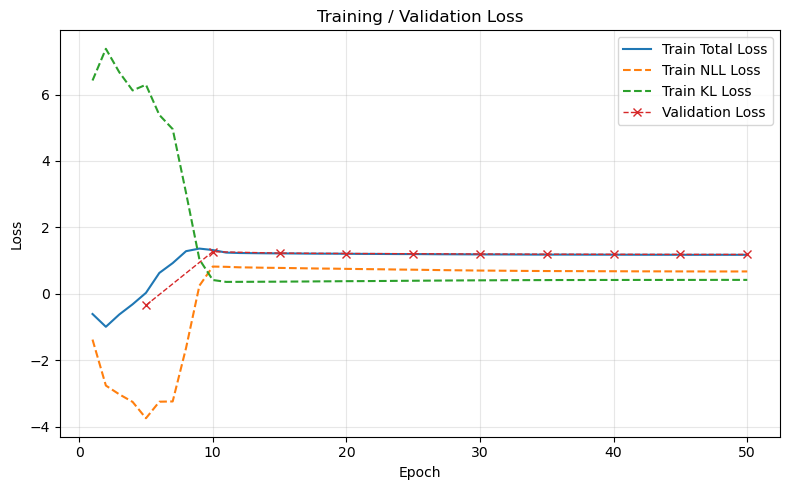

In [24]:
epochs_range = range(1, len(train_total_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_total_losses, label='Train Total Loss')
plt.plot(epochs_range, train_nll_losses, label='Train NLL Loss', linestyle='--')
plt.plot(epochs_range, train_kl_losses, label='Train KL Loss', linestyle='--')

if len(val_total_losses) > 0:
    plt.plot(epochs_range[4::5], val_total_losses, 'x--', label='Validation Loss', linewidth=1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
valModel = CVAE()

scalers = joblib.load("normalizers.pkl")
valModel.attach_normalizers(**scalers)
ckpt = torch.load("cvae_checkpoint.pt", map_location="cpu")
valModel.load_state_dict(ckpt['model_state'])

<All keys matched successfully>

In [26]:
def plot_r_distributions(model, c_n, r_next, n_samples=50000, device="cpu"):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.
    
    Args:
        model: trained CVAE model with attached scalers
        c_n (np.ndarray): conditioning vectors (v_n, r_n), shape [N, c_dim]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3]
        n_samples: number of samples to draw for visualization
        device: torch device
    """
    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    # --- Normalize using model's attached scalers ---
    # assuming first 3 components of c are r, next 3 are v
    v_norm = model.scaler_v.transform(c_s[:, :3])
    r_norm = model.scaler_r.transform(c_s[:, 3:])
    c_norm = np.concatenate([v_norm, r_norm], axis=-1)
    r_next_norm = model.scaler_rnext.transform(r_next_s)

    # --- Forward pass (reconstruction) ---
    model.eval()
    Tr = 1
    with torch.no_grad():
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
        r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)
        dec_out, q, p = model(r_next_t, c_t)
        mu_r, log_sig_r = dec_out
        r_rec_norm = mu_r.cpu().numpy()
        r_rec_norm = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
        r_rec = model.scaler_rnext.inverse_transform(r_rec_norm)

        # --- Generated samples ---
        r_gen = model.sample(c_s, Tr=1, Tz=1)

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["r_x", "r_y", "r_z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for i, ax in enumerate(axes):
        kde_bench = gaussian_kde(r_next_s[:, i])
        kde_rec = gaussian_kde(r_rec[:, i])
        kde_gen = gaussian_kde(r_gen[:, i].flatten())

        xs = np.linspace(
            min(r_next_s[:, i].min(), r_rec[:, i].min(), r_gen[:, i].min()),
            max(r_next_s[:, i].max(), r_rec[:, i].max(), r_gen[:, i].max()),
            300,
        )
        ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[i], lw=2)
        ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")
        ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

        ax.set_title(f"Distribution of {labels[i]}")
        ax.set_xlabel(labels[i])
        ax.set_ylabel("Density")
        ax.set_xlim(-0.05, 0.05)
        ax.legend()

    plt.tight_layout()
    plt.show()

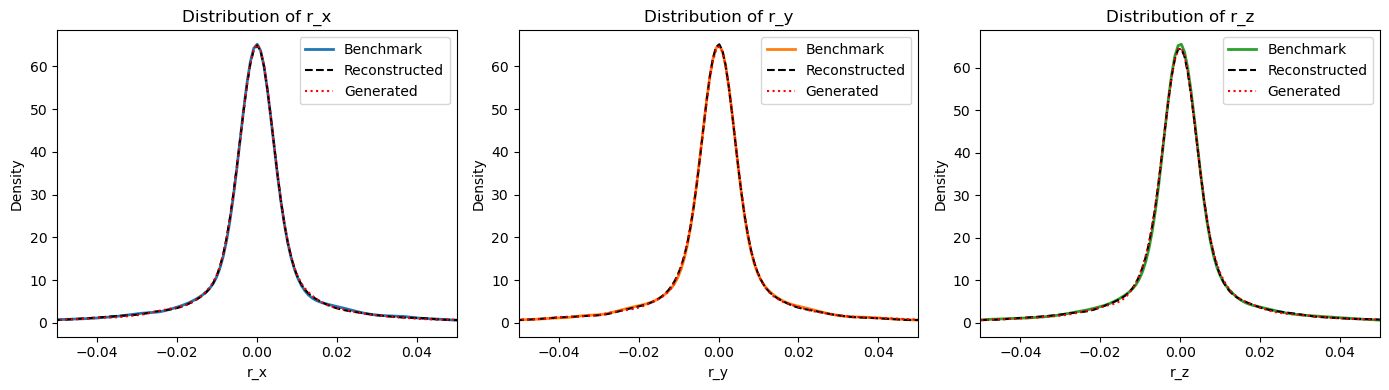

In [27]:
# Assume you have:
# r_n, v_n, r_next = benchmark arrays (each [N,3])
# model = trained CVAE with attached scalers

c_n = np.concatenate([v_n, r_n], axis=-1)

plot_r_distributions(valModel, c_n, r_next, n_samples=20000)

In [28]:
def visualize_latent_distributions(model, c_n, r_next, n_samples=50000, device="cpu"):
    """
    Visualize latent space distributions for encoder vs conditional prior.

    Args:
        model: trained CVAE
        c_n (np.ndarray): conditioning variables (r_n, v_n)
        r_next (np.ndarray): true target variables (r_{n+1})
        n_samples (int): number of samples to analyze
        device: torch device
    """
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    # Normalize
    v_norm = model.scaler_v.transform(c_s[:, :3])
    r_norm = model.scaler_r.transform(c_s[:, 3:])
    c_norm = np.concatenate([v_norm, r_norm], axis=-1)
    
    r_next_norm = model.scaler_rnext.transform(r_next_s)

    # Convert to torch tensors
    c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
    r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        _, (q_mu, q_logv), _ = model(r_next_t, c_t)
        p_mu, p_logv = model.prior_params(c_t)
        q_mu, q_logv = q_mu.cpu().numpy(), q_logv.cpu().numpy()
        p_mu, p_logv = p_mu.cpu().numpy(), p_logv.cpu().numpy()

    q_std = np.exp(0.5 * q_logv)
    p_std = np.exp(0.5 * p_logv)

    zdim = q_mu.shape[1]

    # --- Plot histograms of latent means ---
    fig, axes = plt.subplots(2, zdim, figsize=(4*zdim, 6))
    for i in range(zdim):
        ax = axes[0, i]
        ax.hist(q_mu[:, i], bins=50, alpha=0.6, label="Encoder μ_q", color="tab:blue")
        ax.hist(p_mu[:, i], bins=50, alpha=0.6, label="Prior μ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: means")
        ax.legend()

        ax = axes[1, i]
        ax.hist(q_std[:, i], bins=50, alpha=0.6, label="Encoder σ_q", color="tab:blue")
        ax.hist(p_std[:, i], bins=50, alpha=0.6, label="Prior σ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: stds")
        ax.legend()

    plt.tight_layout()
    plt.show()


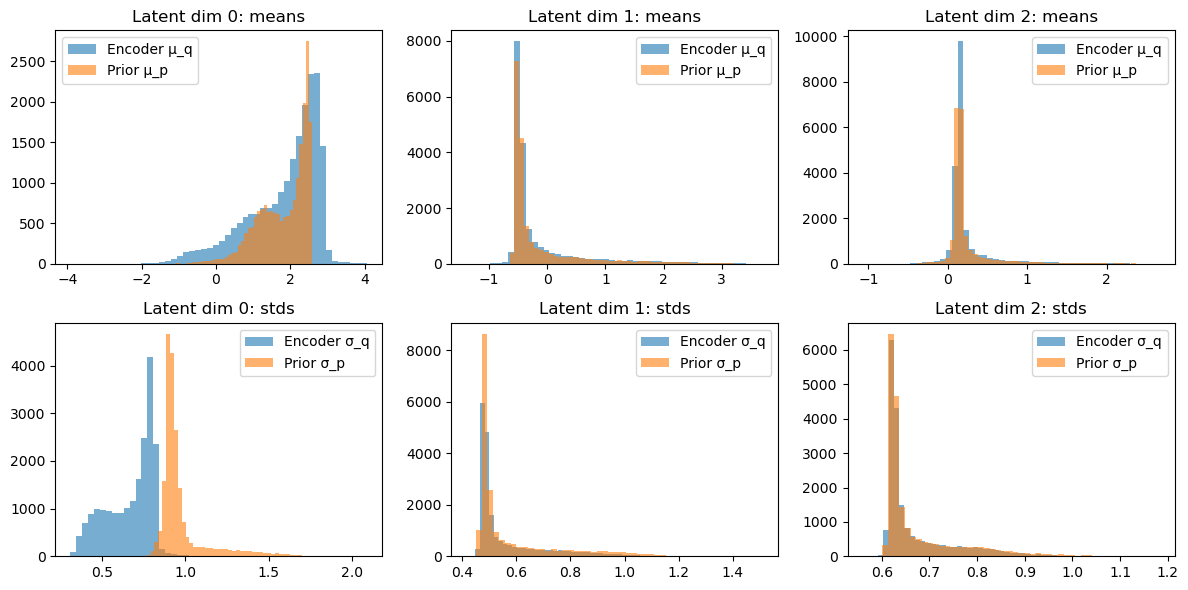

In [29]:
# Assuming you have arrays from benchmark data
# r_n, v_n, r_next -> each [N, 3]
visualize_latent_distributions(valModel, c_n, r_next, n_samples=20000)

In [30]:
batch = next(iter(val_loader))
r_nxt_b, v_b, r_b = batch
c_t = torch.cat((v_b,r_b), dim=-1)

with torch.no_grad():
    dec_out, (q_mu,q_logv), (p_mu,p_logv) = valModel(r_nxt_b, c_t)
    q_std = torch.exp(0.5*q_logv).mean().item()
    p_std = torch.exp(0.5*p_logv).mean().item()
    mu_r, log_sig_r = dec_out
    r_std = torch.exp(log_sig_r).mean().item()
print(f"mean q_std={q_std:.3f}  p_std={p_std:.3f}  decoder_sigma={r_std:.3f}")

mean q_std=0.634  p_std=0.744  decoder_sigma=0.348


In [31]:
def stats(x): 
    x = x.detach().cpu().numpy().reshape(-1)
    qs = np.quantile(x, [0.1,0.5,0.9])
    return f"mean={x.mean():.3f} q10={qs[0]:.3f} q50={qs[1]:.3f} q90={qs[2]:.3f}"
print("p_std:", stats(torch.exp(0.5*p_logv)))
print("q_std:", stats(torch.exp(0.5*q_logv)))
print("dec σ:", stats(torch.exp(log_sig_r)))

p_std: mean=0.744 q10=0.483 q50=0.667 q90=0.972
q_std: mean=0.634 q10=0.477 q50=0.626 q90=0.808
dec σ: mean=0.348 q10=0.181 q50=0.266 q90=0.612
